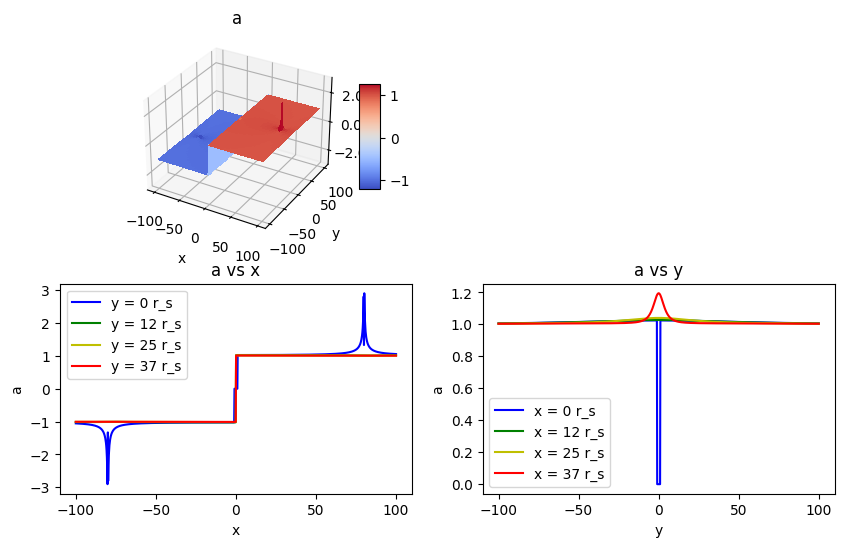

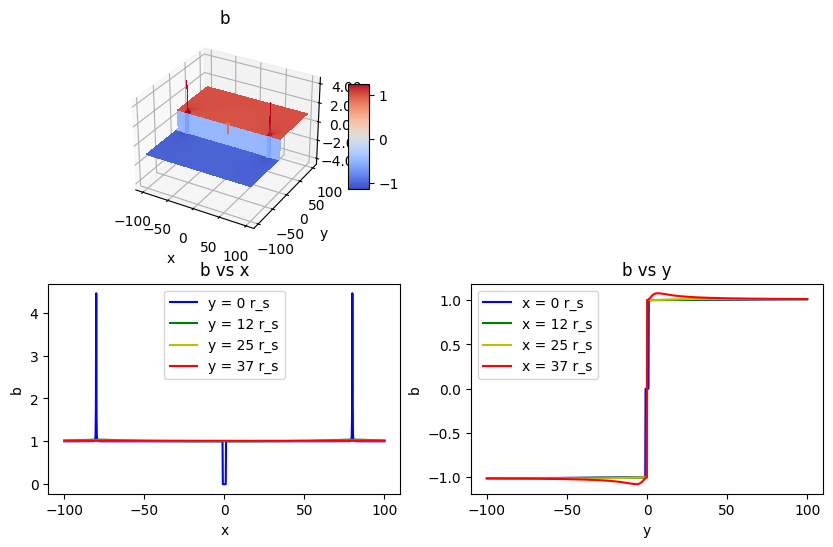

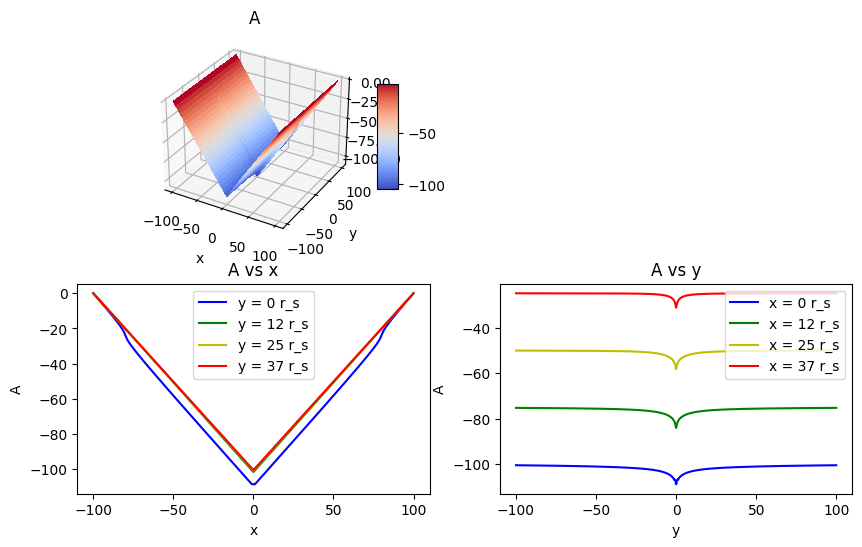

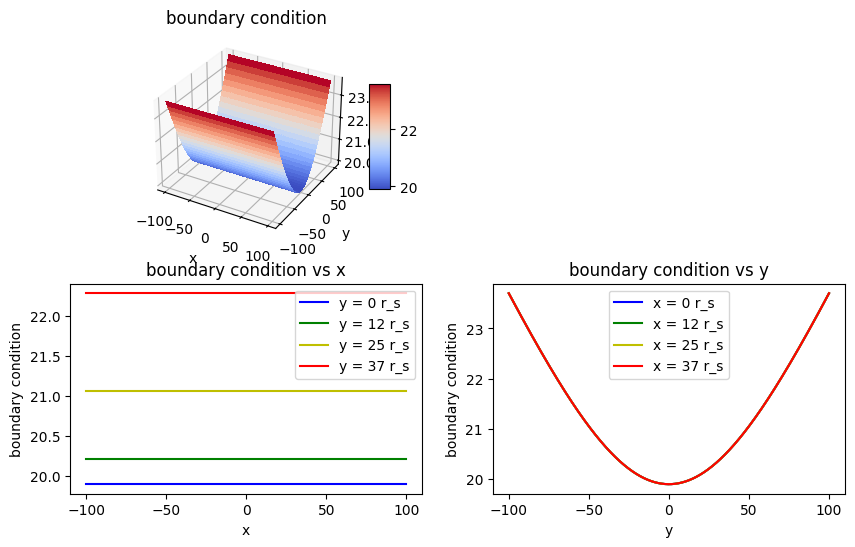

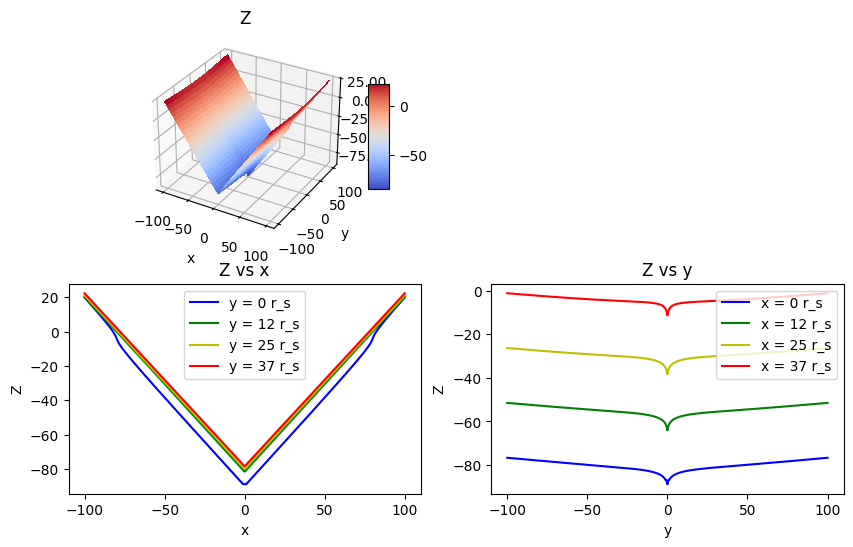

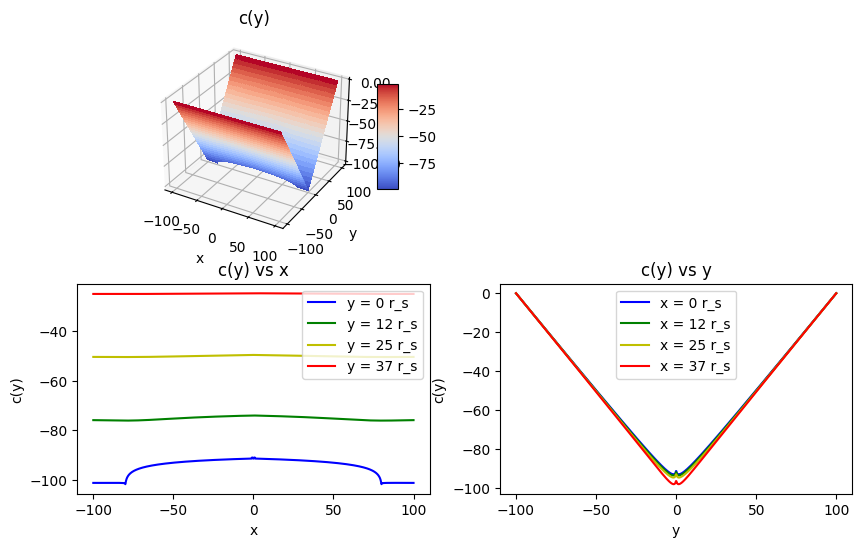

"\n# partial_y_A\nplot_3d_and_slice(partial_y_A, 'A_y')\n# dc_dy\nplot_3d_and_slice(dc_dy, 'dc/dy')\n"

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.integrate import cumulative_trapezoid
from scipy.integrate import trapezoid

### metric
# Schwarzchild linearized
x0 = 80
GM = 1
def g_xx(x, y):
    x1 = x - x0
    x2 = x + x0
    r1 = np.sqrt(x1**2 + y**2)
    r2 = np.sqrt(x2**2 + y**2)
    g1 = 1 + 2*GM * (x1**2)/(r1**3)
    g2 = 1 + 2*GM * (x2**2)/(r2**3)
    return g1 + g2
def g_yy(x, y):
    x1 = x - x0
    x2 = x + x0
    r1 = np.sqrt(x1**2 + y**2)
    r2 = np.sqrt(x2**2 + y**2)
    g1 = 1 + 2*GM * (y**2)/(r1**3)
    g2 = 1 + 2*GM * (y**2)/(r2**3)
    return g1 + g2
def g_xy(x, y):
    x1 = x - x0
    x2 = x + x0
    r1 = np.sqrt(x1**2 + y**2)
    r2 = np.sqrt(x2**2 + y**2)
    g1 = 2*GM * (x1*y)/(r1**3)
    g2 = 2*GM * (x2*y)/(r2**3)
    return g1 + g2

''' check the sign '''
### embedding pde's
def partial_x_Z(x, y):
    return np.sign(x) * np.sqrt(g_xx(x, y) - 1)
def partial_y_Z(x, y):
    return np.sign(y) * np.sqrt(g_yy(x, y) - 1)


### set-up
# constants (change if need)
x_start, x_end = -100, 100
y_start, y_end = -100, 100
n_steps = 1000
delta_x, delta_y = (x_end - x_start) / (n_steps-1), (y_end - y_start) / (n_steps-1)
# coordinates
x_axis = np.linspace(x_start, x_end, n_steps)
y_axis = np.linspace(y_start, y_end, n_steps)
x_meshed, y_meshed = np.meshgrid(x_axis, y_axis)
# creating a 2d np array to copy later on
grid = np.zeros_like(x_meshed)
# r's
r = np.sqrt(x_meshed**2 + y_meshed**2)
r1 = np.sqrt((x_meshed-x0)**2 + y_meshed**2)
r2 = np.sqrt((x_meshed+x0)**2 + y_meshed**2)
# boundary condition
''' should I still use this? '''
boundary_condition = 2*np.sqrt(r[:,0:1] - 1)
boundary_condition = boundary_condition * np.ones_like(grid)
# print(boundary_condition.shape)


### Calculation of Z
# calculating a(x,y) and b(x,y)
''' check this '''
a = np.where((r1<=1.1*GM) | (r2<=1.1*GM), 0, partial_x_Z(x_meshed, y_meshed))
b = np.where((r1<=1.1*GM) | (r2<=1.1*GM), 0, partial_y_Z(x_meshed, y_meshed))

# calculating A: cumulative integral
A = cumulative_trapezoid(a, x=x_axis, axis=1, initial=0)

# calculating Z
Z = A + boundary_condition


### checking c(y)'s x-independence
# calculating partial A
''' what order is np.gradient? '''
partial_y_A = np.gradient(A, y_axis, axis=0)

#calculating d/dy[c(y)]
dc_dy = b - partial_y_A

# calculating c(y) to check its x-independence: cumulative integral
c_check = cumulative_trapezoid(dc_dy, x=y_axis, axis=0, initial=0)



### plotting
# the function
def plot_3d_and_slice(surface, surface_name):
    num_slices = 4

    fig= plt.figure(figsize=(10, 6))
    ax_3d = fig.add_subplot(221, projection='3d')
    ax_slicex = fig.add_subplot(223)
    ax_slicey = fig.add_subplot(224)

    # from matplotlib example (modified)
    surf = ax_3d.plot_surface(x_meshed, y_meshed, surface, cmap=cm.coolwarm, linewidth=0, antialiased=False)
    ax_3d.zaxis.set_major_formatter('{x:.02f}')
    fig.colorbar(surf, shrink=0.5, aspect=5)
    ax_3d.set(xlabel='x', ylabel='y', title=surface_name)
    # ax_3d.set_zlim(bottom=0)

    color = ['b', 'g', 'y' , 'r']
    while len(color) < num_slices:
        color.append['r']
    
    for i in range(num_slices):
         ax_slicex.plot(x_axis, surface[int(len(surface)*(1/2 + i/2/num_slices))], color[i], label=f'y = {int(100*i/2/num_slices)} r_s')
         ax_slicex.set(xlabel='x', ylabel=surface_name, title=f'{surface_name} vs x')
         ax_slicey.plot(y_axis, surface[:,int(len(surface)*(1/2 + i/2/num_slices))], color[i], label=f'x = {int(100*i/2/num_slices)} r_s')
         ax_slicey.set(xlabel='y', ylabel=surface_name, title=f'{surface_name} vs y')
    ax_slicex.legend()
    ax_slicey.legend()
    
    plt.tight_layout
    plt.show()
    return None
# a
plot_3d_and_slice(a, 'a')
# b
plot_3d_and_slice(b, 'b')
# A
plot_3d_and_slice(A, 'A')
# boundary condition
plot_3d_and_slice(boundary_condition, 'boundary condition')
# Z
plot_3d_and_slice(Z, 'Z')
# c(y)
plot_3d_and_slice(c_check, 'c(y)')
'''
# partial_y_A
plot_3d_and_slice(partial_y_A, 'A_y')
# dc_dy
plot_3d_and_slice(dc_dy, 'dc/dy')
'''